# Optimizer-scheduled maintenance

This example shows how to include planned maintenance in a `ConversionDynamic` component. Instead of giving the model fixed maintenance dates, we specify how many maintenance windows are needed and the minimum duration of each window. The optimizer then chooses when the maintenance takes place.

We model a small heating system with one location and 24 hourly time steps. Heat can be supplied in two ways:

- A **boiler** converts fuel into heat. It is the cheaper option, but it must undergo maintenance.
- A **backup heat source** can supply heat directly. It is more expensive and is therefore used only while the boiler is unavailable.

The boiler requires exactly two separate maintenance windows. Each window must last for at least three hours. During maintenance, the boiler is forced offline, so the backup source must meet the heat demand.

The workflow is as follows:

1. Import the required packages.
2. Define the time horizon and create the energy system model.
3. Add the fuel supply, backup source, boiler, and heat demand.
4. Optimize the system.
5. Inspect the hourly operation and maintenance schedule in tables.
6. Visualize boiler operation and the selected maintenance windows.

## 1. Import the required packages

`fine` provides the energy-system components and optimization model. Pandas is used to define the demand profile and present the results, while Matplotlib is used for the final visualization.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import fine as fn

## 2. Create the energy system model

The example covers one day using 24 hourly time steps. The heat demand is constant at 10 kW. Only one location, called `site`, is considered.

The model uses two commodities: `fuel` enters the boiler and `heat` is supplied to the demand.

In [2]:
number_of_time_steps = 24
demand = 10

esM = fn.EnergySystemModel(
    locations={"site"},
    commodities={"fuel", "heat"},
    commodityUnitsDict={"fuel": "kW", "heat": "kW"},
    numberOfTimeSteps=number_of_time_steps,
    hoursPerTimeStep=1,
    verboseLogLevel=0,
)

## 3. Add the system components

### 3.1 Fuel and backup heat

The fuel supply has a cost of 0.05 per kWh. Backup heat costs 1 per kWh, making it much more expensive than heat from the boiler. This cost difference gives the optimizer a reason to operate the boiler whenever it is available and to avoid extending maintenance unnecessarily.

In [3]:
esM.add(
    fn.Source(
        esM=esM,
        name="Fuel supply",
        commodity="fuel",
        hasCapacityVariable=False,
        commodityCost=0.05,
    )
)

esM.add(
    fn.Source(
        esM=esM,
        name="Backup heat",
        commodity="heat",
        hasCapacityVariable=False,
        commodityCost=1,
    )
)

### 3.2 Dynamic boiler with scheduled maintenance

The boiler has a fixed capacity of 10 kW and converts one unit of fuel into one unit of heat. Its maintenance requirement is described by two independent parameters:

- `maintenanceTime=3` means that every maintenance window must remain active for at least three hours.
- `maintenanceOccurrences=2` means that exactly two distinct maintenance windows must be scheduled in this investment period.

The two windows must be separated by at least one timestep without scheduled maintenance. A window may last longer than the minimum duration if doing so benefits the system. In this example, however, backup heat is expensive, so the optimizer has an economic incentive to use exactly the minimum duration.

The maintenance formulation uses binary variables and requires `bigM`. The general FINE input check may report that `bigM` is unused for `hasIsBuiltBinaryVariable`; that warning is harmless here because `bigM` is used by the maintenance formulation instead.

In [4]:
esM.add(
    fn.ConversionDynamic(
        esM=esM,
        name="Boiler",
        physicalUnit="kW",
        commodityConversionFactors={"fuel": -1, "heat": 1},
        hasCapacityVariable=True,
        capacityFix=demand,
        maintenanceTime=3,
        maintenanceOccurrences=2,
        bigM=1000,
    )
)

C:\Bayongwa\Ahana Pa\FINE\fine\utils.py:1395: UserWarning: The declared bigM variable is not used in the problem formulation for hasIsBuiltBinaryVariable, since hasIsBuiltBinaryVariable is set to false. 
Check if bigM is needed for other binary variables (like partLoadMin). Else it is ignored.
  warnings.warn(


### 3.3 Heat demand

The heat demand is fixed at 10 kW in every hour. Consequently, any heat that the boiler cannot provide during maintenance must be supplied by the backup source.

In [5]:
esM.add(
    fn.Sink(
        esM=esM,
        name="Heat demand",
        commodity="heat",
        hasCapacityVariable=False,
        operationRateFix=pd.Series([demand] * number_of_time_steps),
    )
)

## 4. Optimize the energy system

The optimization minimizes total system cost while meeting the heat demand in every timestep. It simultaneously decides when the two maintenance windows occur. A successful run ends with solver status `Optimal` and a gap of 0%.

In [6]:
esM.optimize()

Running HiGHS 1.14.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
MIP has 217 rows; 171 cols; 544 nonzeros; 71 integer variables (71 binary)
Coefficient ranges:
  Matrix  [1e-04, 1e+03]
  Cost    [2e+01, 4e+02]
  Bound   [1e+00, 1e+01]
  RHS     [1e+00, 1e+00]
Presolving model
188 rows, 117 cols, 436 nonzeros 0s
92 rows, 69 cols, 268 nonzeros 0s
68 rows, 44 cols, 218 nonzeros 0s
67 rows, 44 cols, 219 nonzeros 0s
Presolve reductions: rows 67(-150); columns 44(-127); nonzeros 219(-325) 

Solving MIP model with:
   67 rows
   44 cols (44 binary, 0 integer, 0 implied int., 0 continuous, 0 domain fixed)
   219 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z =

## 5. Inspect the optimization results

FINE stores the boiler's operation in `operationVariablesOptimum`. The new `maintenanceActiveVariablesOptimum` result records whether scheduled maintenance is active in each timestep: a value of 1 means that the boiler is under maintenance, while 0 means that it is available. This time series is also included in the standard xarray and netCDF exports.

The first table presents the complete hourly schedule. `Backup heat` is calculated as demand minus boiler operation, making it easy to see how the system replaces the unavailable boiler output.

In [7]:
model = esM.componentModelingDict["ConversionDynamicModel"]
operation = model.operationVariablesOptimum.loc["Boiler", "site"]
maintenance = model.maintenanceActiveVariablesOptimum.loc["Boiler", "site"]

result_table = pd.DataFrame(
    {
        "Boiler operation [kW]": operation,
        "Maintenance active": maintenance.gt(0.5).astype(int),
        "Backup heat [kW]": demand - operation,
    }
)
result_table.index.name = "Time step"
result_table

,Boiler operation [kW],Maintenance active,Backup heat [kW]
Time step,,,
0,1.000000e+01,0,0.0
1,1.000000e+01,0,0.0
2,1.000000e+01,0,0.0
3,1.000000e+01,0,0.0
4,1.000000e+01,0,0.0
5,1.443290e-14,1,10.0
6,1.443290e-14,1,10.0
7,1.443290e-14,1,10.0
8,1.000000e+01,0,0.0


### 5.1 Maintenance-window summary

The next table reduces the hourly values to one row per maintenance window. It reports the first active timestep, the last active timestep, and the duration. The result should contain exactly two rows, and each duration should be at least three hours. The exact timing can differ between solvers because several schedules may have the same total cost.

In [8]:
active = result_table["Maintenance active"].astype(bool)
window_starts = active & ~active.shift(fill_value=False)
window_number = window_starts.cumsum()
active_steps = result_table.loc[active].reset_index()
active_steps["Window"] = window_number.loc[active].to_numpy()

maintenance_windows = (
    active_steps.groupby("Window")
    .agg(
        start_time_step=("Time step", "min"),
        end_time_step=("Time step", "max"),
        duration_hours=("Time step", "size"),
    )
    .rename_axis("Maintenance window")
)
maintenance_windows

,start_time_step,end_time_step,duration_hours
Maintenance window,,,
1,5,7,3
2,11,13,3


## 6. Visualize the maintenance schedule

The blue line shows boiler operation, and the area beneath it is marked with thin diagonal hatching to make the boiler's operating periods easy to recognize. The dashed green line shows backup heat supply. The red shaded areas show the periods in which scheduled maintenance is active. Outside maintenance, the boiler supplies the full demand and backup heat remains at zero. During maintenance, boiler output falls to zero and backup heat rises to 10 kW. The two supply lines therefore complement each other and always add up to the fixed heat demand.

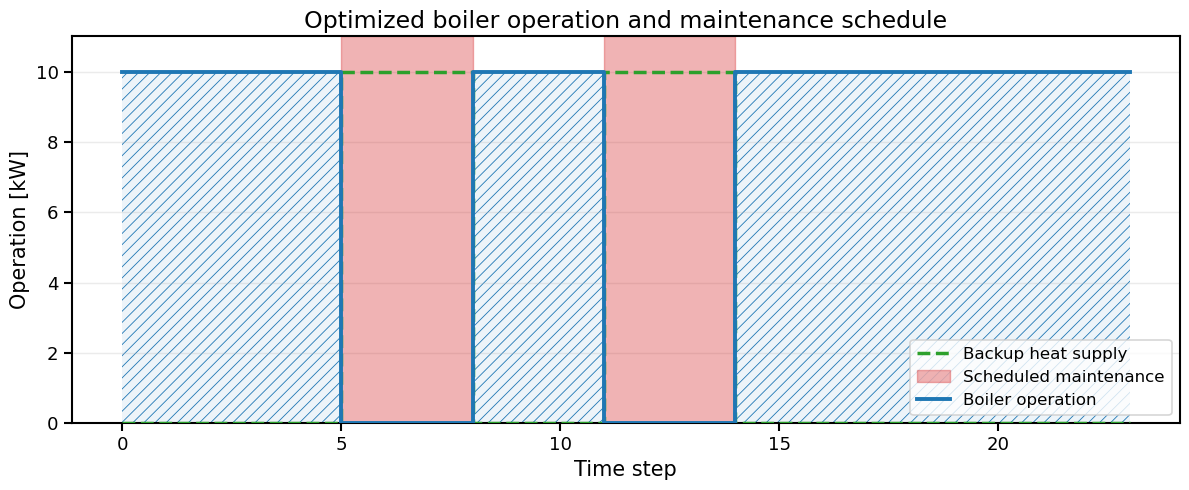

In [9]:
figure, axis = plt.subplots(figsize=(12, 5))
previous_hatch_linewidth = plt.rcParams["hatch.linewidth"]
plt.rcParams["hatch.linewidth"] = 0.6
axis.fill_between(
    operation.index,
    0,
    operation,
    step="post",
    facecolor=(0.12, 0.47, 0.71, 0.08),
    edgecolor="tab:blue",
    hatch="///",
    linewidth=0,
    zorder=1,
)
plt.rcParams["hatch.linewidth"] = previous_hatch_linewidth
axis.step(
    result_table.index,
    result_table["Backup heat [kW]"],
    where="post",
    linewidth=2.5,
    linestyle="--",
    color="tab:green",
    label="Backup heat supply",
    zorder=3,
)
for window, values in maintenance_windows.iterrows():
    axis.axvspan(
        values["start_time_step"],
        values["end_time_step"] + 1,
        alpha=0.35,
        color="tab:red",
        label="Scheduled maintenance" if window == 1 else None,
        zorder=2,
    )
axis.step(
    operation.index,
    operation,
    where="post",
    color="tab:blue",
    linewidth=2.8,
    label="Boiler operation",
    zorder=5,
)
axis.set_title("Optimized boiler operation and maintenance schedule", fontsize=17)
axis.set_xlabel("Time step", fontsize=15)
axis.set_ylabel("Operation [kW]", fontsize=15)
axis.set_ylim(0, demand * 1.1)
axis.tick_params(axis="both", labelsize=13, width=1.5, length=6)
axis.grid(axis="y", alpha=0.25, linewidth=1)
for spine in axis.spines.values():
    spine.set_linewidth(1.5)
legend = axis.legend(fontsize=12, frameon=True)
legend.get_frame().set_linewidth(1.2)
figure.tight_layout()
plt.show()

## 7. Verify the xarray export

The optimized maintenance schedule is automatically included in FINE's standard xarray and netCDF result exports. The following compact check creates the in-memory xarray export and confirms that the boiler dataset contains `maintenanceActiveVariablesOptimum`. A result of `True` means that the maintenance schedule is available to the export infrastructure. Detailed export correctness, including a netCDF write-and-read round trip, is covered by the automated tests.

In [10]:
from fine.IOManagement import xarrayIO

datasets = xarrayIO.writeEnergySystemModelToDatasets(esM)
exported_results = datasets["Results"][0]["ConversionDynamicModel"]["Boiler"]

"maintenanceActiveVariablesOptimum" in exported_results

True

## 8. Interpretation

The optimized schedule illustrates the main behavior of independent maintenance windows:

- Exactly two maintenance windows are selected.
- Each selected window lasts for at least three hours.
- The windows are distinct and have at least one non-maintenance timestep between them.
- Boiler operation is zero whenever maintenance is active.
- The backup source supplies 10 kW during maintenance and remains at zero while the boiler is operating.
- Maintenance timing is chosen by the optimizer and is independent of `downTimeMin`.

Because heat demand and costs are constant throughout this small example, several placements of the two windows are equally optimal. A real model with changing demand, prices, or renewable availability would tend to place maintenance in periods where taking the component offline has the lowest system cost.